Importing Dependencies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, recall_score, make_scorer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
print('Imported')

Imported


Data Pre-Processing

In [2]:
df = pd.read_csv("D:\GitHub Project\Lifestyle\Lifestyle_and_Health_Risk_Prediction_Synthetic_Dataset.csv")
df.head()

,age,weight,height,exercise,sleep,sugar_intake,smoking,alcohol,married,profession,bmi,health_risk
0,56,67,195,low,6.1,medium,yes,yes,yes,office_worker,17.6,high
1,69,76,170,high,6.9,high,no,no,no,teacher,26.3,high
2,46,106,153,high,6.6,low,yes,no,no,artist,45.3,high
3,32,54,186,medium,8.5,medium,no,no,no,artist,15.6,low
4,60,98,195,high,8.0,low,no,no,yes,teacher,25.8,high


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           5000 non-null   int64  
 1   weight        5000 non-null   int64  
 2   height        5000 non-null   int64  
 3   exercise      5000 non-null   object 
 4   sleep         5000 non-null   float64
 5   sugar_intake  5000 non-null   object 
 6   smoking       5000 non-null   object 
 7   alcohol       5000 non-null   object 
 8   married       5000 non-null   object 
 9   profession    5000 non-null   object 
 10  bmi           5000 non-null   float64
 11  health_risk   5000 non-null   object 
dtypes: float64(2), int64(3), object(7)
memory usage: 468.9+ KB


In [4]:
df.shape

(5000, 12)

In [5]:
# since we already have the BMI columns which is the calculation of weight / (height * height)
# so its better to drop those 2 columns
df = df.drop(columns=['weight','height'])

In [6]:
df.head()

,age,exercise,sleep,sugar_intake,smoking,alcohol,married,profession,bmi,health_risk
0,56,low,6.1,medium,yes,yes,yes,office_worker,17.6,high
1,69,high,6.9,high,no,no,no,teacher,26.3,high
2,46,high,6.6,low,yes,no,no,artist,45.3,high
3,32,medium,8.5,medium,no,no,no,artist,15.6,low
4,60,high,8.0,low,no,no,yes,teacher,25.8,high


Exploratory Data Analysis (EDA)

In [7]:
df.describe()

,age,sleep,bmi
count,5000.000000,5000.000000,5000.00000
mean,48.805600,6.997060,26.84388
std,17.906991,1.432849,8.25249
min,18.000000,3.000000,11.40000
25%,34.000000,6.000000,20.30000
50%,49.000000,7.000000,26.00000
75%,64.000000,8.000000,32.40000
max,79.000000,10.000000,51.40000


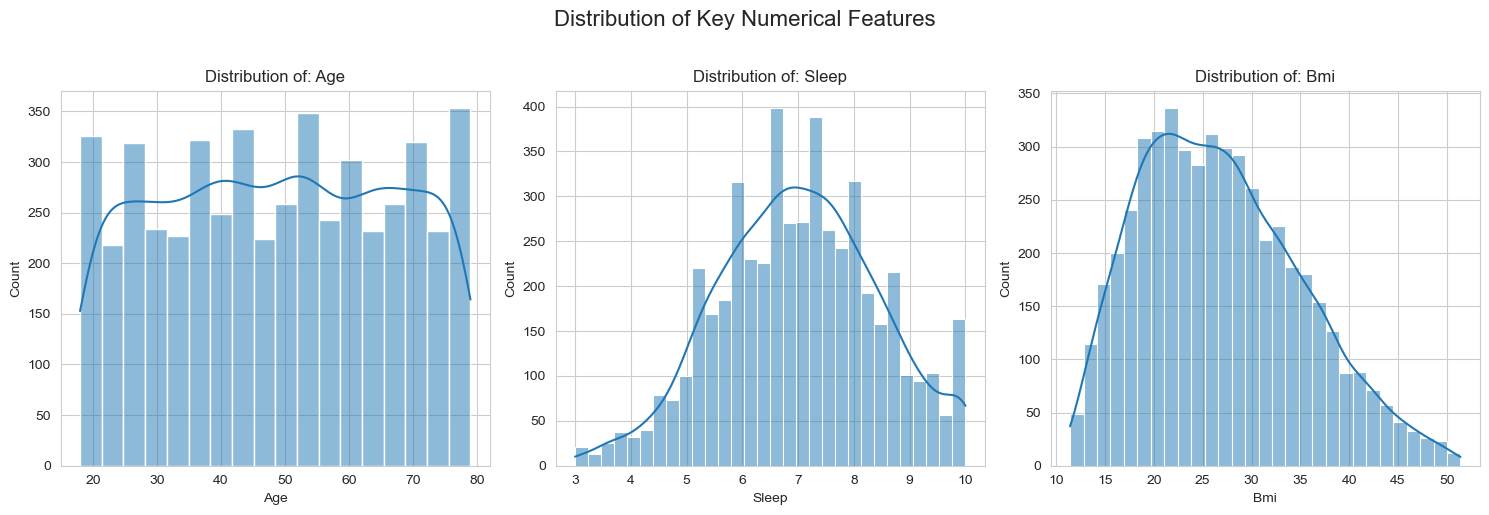

In [8]:
# lest visualize the numerical features 
numerical_features = ['age', 'sleep', 'bmi']
sns.set_style('whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plt.suptitle('Distribution of Key Numerical Features', fontsize=16, y=1.02)
for i, column in enumerate(numerical_features):
    sns.histplot(df[column], kde=True, ax=axes[i]) 
    axes[i].set_title(f'Distribution of: {column.title()}', fontsize=12)
    axes[i].set_xlabel(column.title())

plt.tight_layout() 
plt.show()

In [9]:
df.columns

Index(['age', 'exercise', 'sleep', 'sugar_intake', 'smoking', 'alcohol',
       'married', 'profession', 'bmi', 'health_risk'],
      dtype='object')

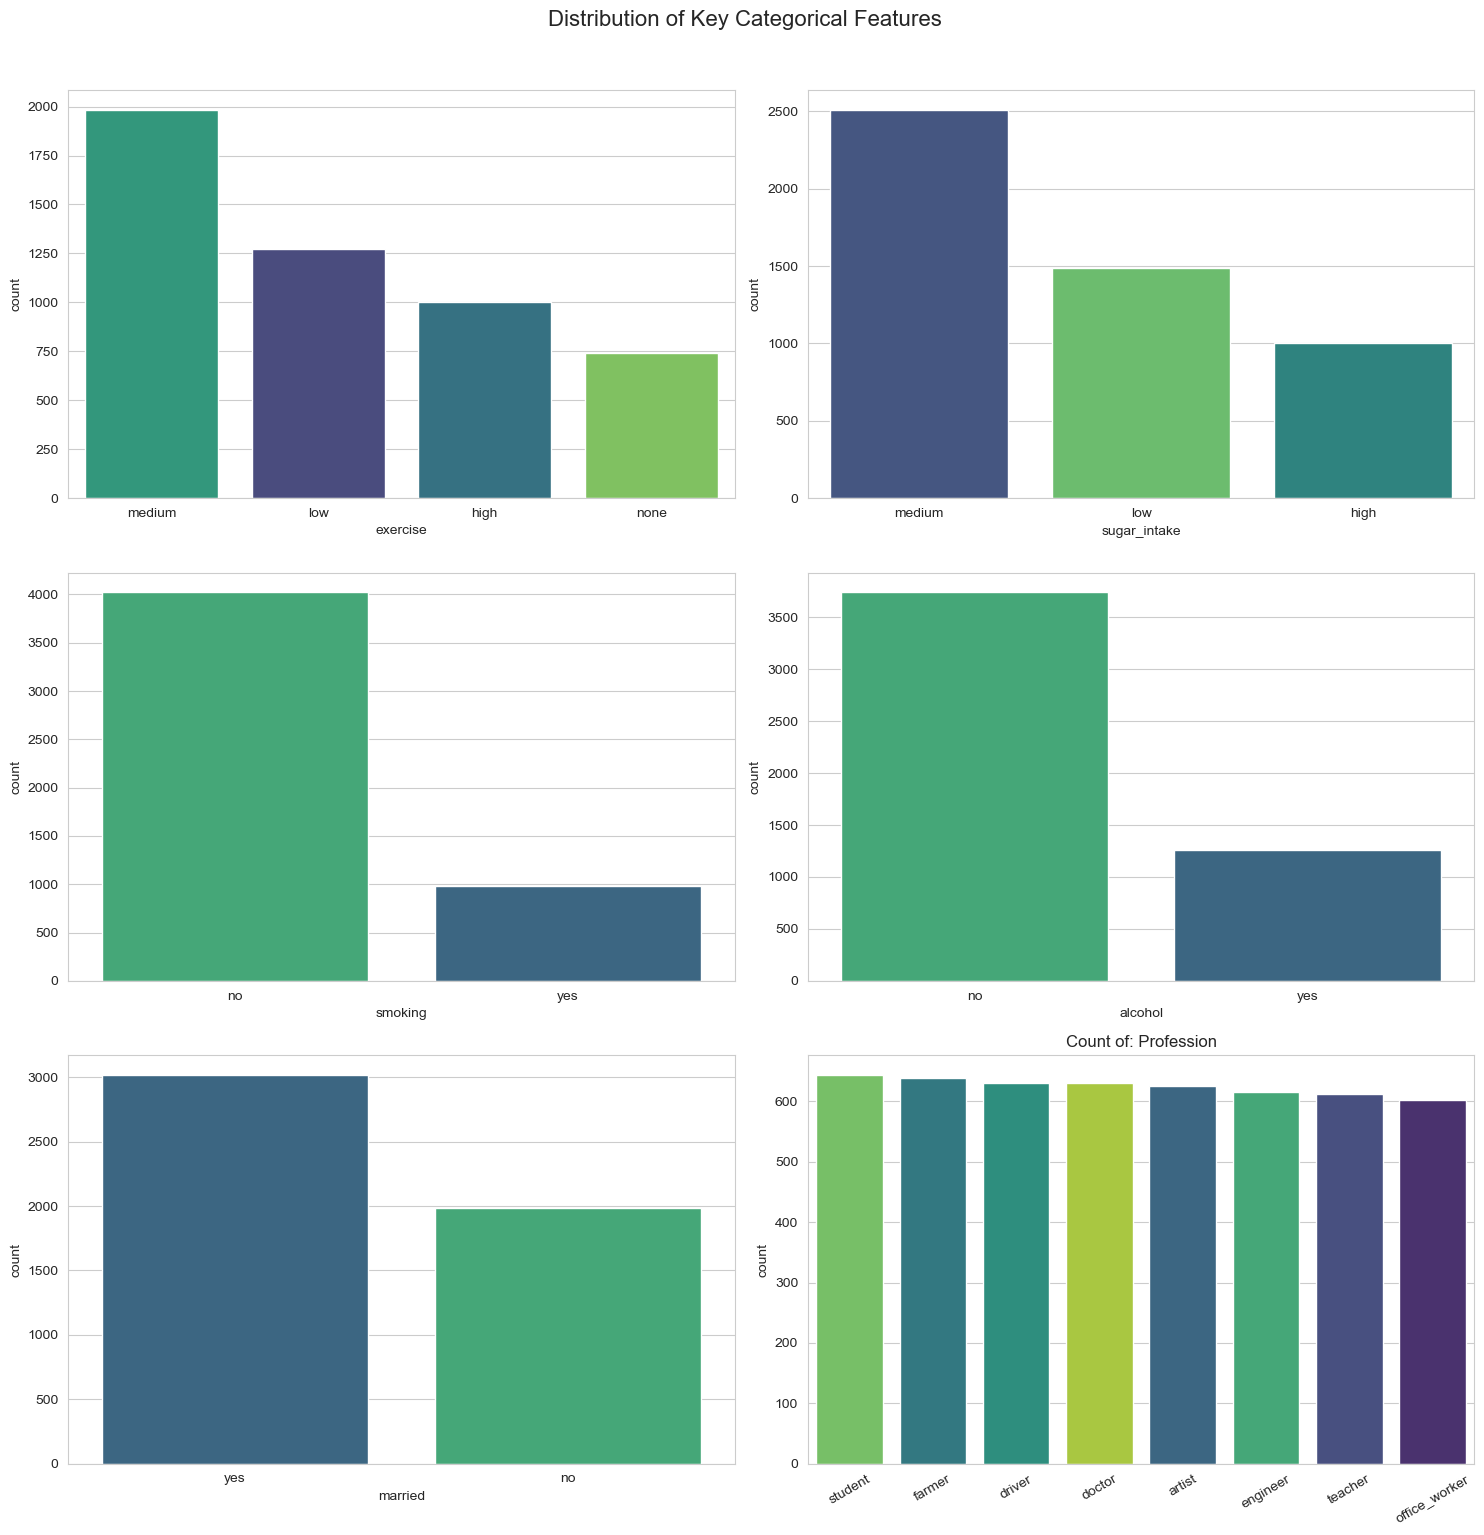

In [10]:
# now let see the distribution of categorical features

categorical_features = ['exercise', 'sugar_intake', 'smoking', 'alcohol', 'married', 'profession']
sns.set_style('whitegrid')
fig, axes = plt.subplots(3, 2, figsize=(15, 15)) 
plt.suptitle('Distribution of Key Categorical Features', fontsize=16, y=1.02)
axes_flat = axes.flatten()

for i, column in enumerate(categorical_features):
    ax = axes_flat[i]
    
    sns.countplot(
        x=column, 
        data=df, 
        ax=ax, 
        palette='viridis', 
        hue=column,           
        legend=False,         
        order=df[column].value_counts().index
    ) 
    
ax.set_title(f'Count of: {column.title()}', fontsize=12)
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

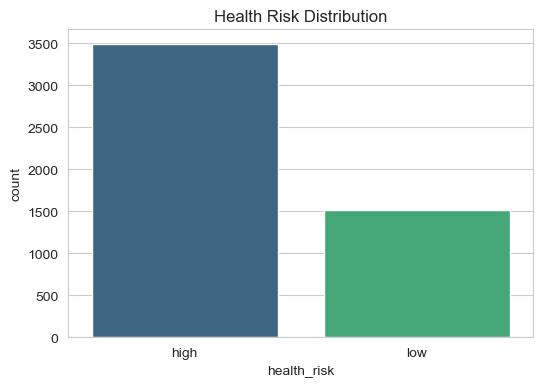

In [11]:
# now lets take a loof of our target variable distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='health_risk', data=df, palette='viridis', hue='health_risk', legend=False)
plt.title('Health Risk Distribution')
plt.show()

In [12]:
df['health_risk'].value_counts()

health_risk
high    3490
low     1510
Name: count, dtype: int64

In [13]:
df.columns

Index(['age', 'exercise', 'sleep', 'sugar_intake', 'smoking', 'alcohol',
       'married', 'profession', 'bmi', 'health_risk'],
      dtype='object')

In [14]:
print('exercise:', df['exercise'].unique())
print('sugar intake:', df['sugar_intake'].unique())
print('smoking:', df['smoking'].unique())
print('alcohol:', df['alcohol'].unique())
print('profession:', df['profession'].unique())
print('married:', df['married'].unique())
print('health risk:', df['health_risk'].unique())

exercise: ['low' 'high' 'medium' 'none']
sugar intake: ['medium' 'high' 'low']
smoking: ['yes' 'no']
alcohol: ['yes' 'no']
profession: ['office_worker' 'teacher' 'artist' 'farmer' 'driver' 'engineer' 'student'
 'doctor']
married: ['yes' 'no']
health risk: ['high' 'low']


Features Engineering

In [15]:
# list all categorical features for encoding
numerical_features = ['age', 'bmi', 'sleep'] 
categorical_features = ['exercise', 'sugar_intake', 'smoking', 'alcohol', 'married', 'profession']

In [16]:
# Rename values in the 'smoking' column for clarity
df['smoking'] = df['smoking'].replace({
    'yes': 'Smoker',
    'no': 'Non-Smoker'
})
# Rename values in the 'alcohol' column for clarity
df['alcohol'] = df['alcohol'].replace({
    'yes': 'Consumer',
    'no': 'Non-Consumer'
})
# Rename values in the 'married' column for clarity
df['married'] = df['married'].replace({
    'yes': 'Married',
    'no': 'Non-Married'
})

In [17]:
df.head()

,age,exercise,sleep,sugar_intake,smoking,alcohol,married,profession,bmi,health_risk
0,56,low,6.1,medium,Smoker,Consumer,Married,office_worker,17.6,high
1,69,high,6.9,high,Non-Smoker,Non-Consumer,Non-Married,teacher,26.3,high
2,46,high,6.6,low,Smoker,Non-Consumer,Non-Married,artist,45.3,high
3,32,medium,8.5,medium,Non-Smoker,Non-Consumer,Non-Married,artist,15.6,low
4,60,high,8.0,low,Non-Smoker,Non-Consumer,Married,teacher,25.8,high


In [18]:
X = df.drop('health_risk', axis=1)
# Map target to numerical (1/0) for classifier, and rename columns for clean separation
y = df['health_risk'].map({'high': 1, 'low': 0}) 
target_names = ['Low Risk (0)', 'High Risk (1)']

In [19]:
print(X)
print(y)

      age exercise  sleep sugar_intake     smoking       alcohol      married  \
0      56      low    6.1       medium      Smoker      Consumer      Married   
1      69     high    6.9         high  Non-Smoker  Non-Consumer  Non-Married   
2      46     high    6.6          low      Smoker  Non-Consumer  Non-Married   
3      32   medium    8.5       medium  Non-Smoker  Non-Consumer  Non-Married   
4      60     high    8.0          low  Non-Smoker  Non-Consumer      Married   
...   ...      ...    ...          ...         ...           ...          ...   
4995   42   medium    7.2          low  Non-Smoker  Non-Consumer      Married   
4996   39      low    7.4          low  Non-Smoker  Non-Consumer      Married   
4997   48     none    7.2         high      Smoker      Consumer      Married   
4998   34   medium    9.9       medium  Non-Smoker  Non-Consumer      Married   
4999   72     high    6.3       medium  Non-Smoker  Non-Consumer      Married   

         profession   bmi  

In [20]:
# Lets start the transformer for numerical features.
# StandardScaler removes the mean and scales the data to unit variance (mean=0, std=1).
numerical_transformer = StandardScaler()
# OneHotEncoder converts categorical text data into a format understandable by ML models
categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
# Combine the transformers into a single preprocessor.
# ColumnTransformer applies different transformations to specific columns based on their data type.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        # Apply the numerical transformer (StandardScaler) to the list of columns specified in 'numerical_features'.
        ('cat', categorical_transformer, categorical_features)
        # Apply the categorical transformer (OneHotEncoder) to the list of columns specified in 'categorical_features'.
    ]
)

Model Training

In [21]:
# Split the data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [22]:
# Use class_weight='balanced' to handle the health_risk imbalance
classifier = RandomForestClassifier(
    n_estimators=500,      # The number of decision trees in the forest. 
    class_weight='balanced', # Adjusts weights inversely proportional to class frequencies.
    random_state=42,       # Restrict the size of the final leaf nodes
    min_samples_leaf=10,   # Enforce at least 10 samples per final leaf
    
    max_features='sqrt'    # Restrict the number of features considered at each split    
)

# Final Model Pipeline
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', classifier)
])

In [23]:
# Train the model on the training data
model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'bmi', 'sleep']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['exercise', 'sugar_intake',
                                                   'smoking', 'alcohol',
                                                   'married',
                                                   'profession'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        min_samples_leaf=10, n_estimators=500,
                                        random_state=42))])

Model Evaluation

In [25]:
y_pred = model_pipeline.predict(X_test)

print('==== Evaluation Metrics (Focus on Recall for High Risk) ====')
print(classification_report(y_test, y_pred, target_names=target_names))
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))

==== Evaluation Metrics (Focus on Recall for High Risk) ====
               precision    recall  f1-score   support

 Low Risk (0)       0.96      0.99      0.97       302
High Risk (1)       1.00      0.98      0.99       698

     accuracy                           0.98      1000
    macro avg       0.98      0.99      0.98      1000
 weighted avg       0.98      0.98      0.98      1000

Confusion Matrix:
[[299   3]
 [ 14 684]]


In [26]:
import joblib
# Save the entire trained pipeline object
joblib.dump(model_pipeline, 'Lifestyile And Health Risk Prediction.joblib')

['Lifestyile And Health Risk Prediction.joblib']